# Import Libraries and Data

In [1]:
import hyperspy.api as hs
hs.preferences.array_backend = "cupy"
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

#%matplotlib qt

In [2]:
mpl.rcParams['figure.figsize'] = (12,6)
mpl.rcParams['axes.titlesize'] = 16
#mpl.rcParams['axes.xmargin'] = 0.05
mpl.rcParams['axes.ymargin'] = 0.25
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.linestyle'] = '-'
#plt.style.use('ggplot')
mpl.rcParams['lines.markersize'] = 3
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['ytick.minor.size'] = 5
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams["xtick.minor.visible"] =  False
mpl.rcParams["ytick.minor.visible"] =  False
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams["xtick.top"] = False
mpl.rcParams["ytick.right"] = False
mpl.rcParams['xtick.minor.pad'] = 10 #distance between axis and axis label
mpl.rcParams['ytick.minor.pad'] = 10
mpl.rcParams['xtick.major.pad'] = 10
mpl.rcParams['ytick.major.pad'] = 10


In [3]:
from matplotlib.colors import LinearSegmentedColormap
custom_colors = [ '#000000','#000090','#00FFFF','#00cb00','#66FF33','#ffff00','#FF9900','#ff0000','#FF00FF']
#custom_colors = [ '#000000','#000032','#000070','#00FFFF','#33ff99','#66FF33','#00cb00','#80e500','#ffff00','#ffcc00','#FF9900','#ff4c00','#ff0000','#FF00FF']
my_map = LinearSegmentedColormap.from_list("my_cmap", custom_colors, N=256)

In [4]:
# Load data
cs = hs.load(r'C:\Users\nagaa\Desktop\00_View008\View008_0000807.pts', lazy=False, rebin_energy=1,  cutoff_at_kV=20.0, downsample=1, sum_frames=True, only_valid_data=True, read_em_image=True)

In [ ]:
cs[0].axes_manager[2].offset -= 0.01

In [5]:
data1 = cs[0].isig[0.0:20.0].deepcopy()

In [6]:
data1.original_metadata

├── EDS Data
│   └── AnalyzableMap MeasData
│       ├── Data
│       │   ├── DigitalMap
│       │   └── EDXRF = array([0, 0, 0, ..., 0, 0, 0], dtype=int32)
│       ├── Doc
│       │   ├── CoefA = np.float64(0.00999862)
│       │   ├── CoefB = np.float64(0.000117212)
│       │   ├── CountRate
│       │   │   ├── n = np.int32(2302)
│       │   │   ├── sum = array([3.99118900e+07, 7.51765215e+11])
│       │   │   └── value = np.int32(8355)
│       │   ├── DeadTime
│       │   │   ├── n = np.int32(2302)
│       │   │   ├── sum = array([  59135., 1629639.])
│       │   │   └── value = np.uint16(7)
│       │   ├── DwellTime(msec) = np.float64(0.1)
│       │   ├── Esc = np.float64(1.75)
│       │   ├── LiveTime = np.float64(696.28)
│       │   ├── RealTime = np.float64(968.9)
│       │   ├── ScanLine = np.uint16(512)
│       │   └── Sweep = np.uint16(37)
│       ├── MeasCond
│       │   ├── AccKV = np.float32(200.0)
│       │   ├── AccNA = np.float32(7.475)
│       │   ├── FocusMP = np.int32(16043213)
│       │   ├── Mag = np.int32(80000)
│       │   ├── ScanR = np.float32(280.0)
│       │   └── WD = np.float32(3.2)
│       └── Meas Cond
│           ├── Aim Area = array([  0,   0, 511, 511], dtype=uint16)
│           ├── LTDwellT = np.False_
│           ├── Pixels = 512x512
│           └── Tpl = T4
├── PTTD Cond
│   └── Meas Cond
│       ├── CONDPAGE0_C.R
│       │   ├── DataFhdrsp = np.int32(32768)
│       │   ├── DataFname = C:\Users\JEOL\AppData\Local\Temp\Map2\26d4\944386906.PTS
│       │   ├── DwellT
│       │   │   ├── List <list>
│       │   │   │   ╠══ [0] =  0.01 msec.
│       │   │   │   ╠══ [1] =  0.02 msec.
│       │   │   │   ╠══ [10] = 10.0 msec.
│       │   │   │   ╠══ [11] = 20.0 msec.
│       │   │   │   ╠══ [12] = 50.0 msec.
│       │   │   │   ╠══ [13] = 100.0 msec.
│       │   │   │   ╠══ [2] =  0.03 msec.
│       │   │   │   ╠══ [3] =  0.05 msec.
│       │   │   │   ╠══ [4] =  0.1 msec.
│       │   │   │   ╠══ [5] =  0.2 msec.
│       │   │   │   ╠══ [6] =  0.5 msec.
│       │   │   │   ╠══ [7] =  1.0 msec.
│       │   │   │   ╠══ [8] =  2.0 msec.
│       │   │   │   ╚══ [9] =  5.0 msec.
│       │   │   └── index = np.uint16(4)
│       │   ├── ITC
│       │   │   ├── COEFR = np.float64(0.0)
│       │   │   ├── INT = np.int32(5)
│       │   │   ├── LOSSLESS = np.True_
│       │   │   ├── List = ['None', 'SEI']
│       │   │   ├── MAG = np.int32(80000)
│       │   │   ├── Off = np.True_
│       │   │   ├── ROT = np.float64(280.0)
│       │   │   ├── TIRes = 512x512
│       │   │   └── index = np.uint16(1)
│       │   ├── KeepExtS = np.False_
│       │   ├── LTDwellT = np.False_
│       │   ├── MeasOBJ
│       │   │   ├── SEI = np.True_
│       │   │   └── X-ray = np.True_
│       │   ├── MiniOBJs = ['SEI', 'O K', 'Co K', 'Sr K', 'La L']
│       │   ├── Pixels
│       │   │   ├── List = ['64x64', '128x128', '256x256', '512x512', '1024x1024', '2048x2048', '4096x4096']
│       │   │   └── index = np.uint16(3)
│       │   ├── RapidScan = np.False_
│       │   ├── Sweep
│       │   │   ├── List = ['OFF', '1', '5', '10', '50', '100']
│       │   │   ├── Val = np.uint16(65535)
│       │   │   └── index = np.uint16(1)
│       │   ├── Tpl
│       │   │   ├── List = ['T1', 'T2', 'T3', 'T4']
│       │   │   └── index = np.uint16(3)
│       │   └── ZPProf = np.False_
│       └── CONDPAGE1_SEM
│           ├── AAC = np.int32(0)
│           ├── AccKV = np.float32(200.0)
│           ├── AccKVSet = np.False_
│           ├── AccNA = np.float32(7.475)
│           ├── HTOff = np.False_
│           ├── IgnoreHT = np.False_
│           ├── InvokeAFMP = np.False_
│           ├── Mag = np.int32(80000)
│           ├── MagSet = np.False_
│           ├── PhotoFname = 
│           └── TakePhoto = np.False_
├── PTTD Data
│   └── AnalyzableMap MeasData
│       ├── Data
│       │   └── DigitalMap
│       ├── Doc
│       │   ├── CoefA = np.float64(0.00999862)
│       │   ├── CoefB = np.float64(0.000117212)
│       │   ├── CountRate
│       │   │ 

In [7]:
data1.data.shape

(512, 512, 2000)

In [8]:
data1 = data1.rebin(scale=(4,4,1))#if required

In [9]:
background_image = cs[1].rebin(scale=(4,4))#if required

In [10]:
data1.axes_manager[0].scale*=1000
data1.axes_manager[0].units = 'nm'
data1.axes_manager[1].scale*=1000
data1.axes_manager[1].units = 'nm'

In [11]:
data1.set_elements(['Co','La','Sr','Cu','C','O','Fe'])
data1.add_lines(['Sr_Ka','Sr_La','Sr_Lb1','La_La','La_Lb1','La_Lb2','La_Lg1','La_Lg3','La_Lb3','La_Lb4','Co_Ka','Co_Kb','Co_La','Cu_Ka','Cu_Kb','Cu_La','Fe_Ka'])

In [12]:
data1.set_microscope_parameters(beam_energy=data1.original_metadata['PTTD Cond']['Meas Cond']['CONDPAGE1_SEM']['AccKV'],
    live_time=data1.original_metadata['PTTD Data']['AnalyzableMap MeasData']['Doc']['LiveTime'],
    tilt_stage=0,
    azimuth_angle=90,
    elevation_angle=21.5,
    energy_resolution_MnKa=133,
    beam_current=data1.original_metadata['PTTD Cond']['Meas Cond']['CONDPAGE1_SEM']['AccNA'],
    probe_area=data1.axes_manager[0].scale,
    real_time=data1.original_metadata['PTTD Data']['AnalyzableMap MeasData']['Doc']['RealTime'],
    display=True,
    toolkit=None)

In [13]:
total_counts = np.sum(data1.data, axis=2)

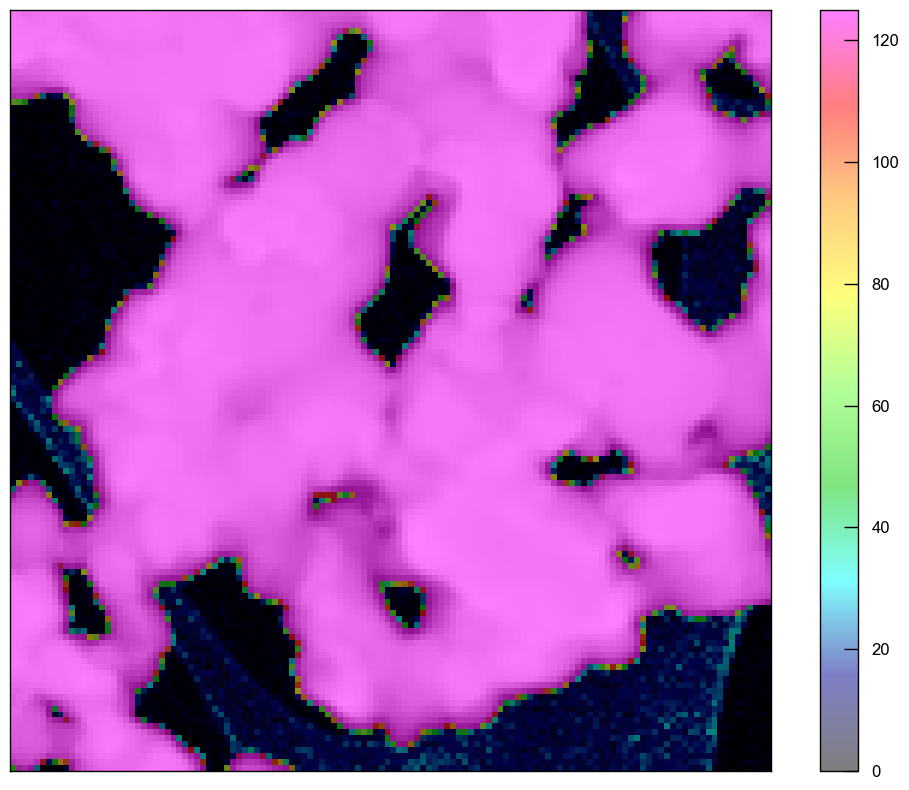

In [14]:
ax1 = plt.figure(figsize=(10,8))

# Plot first image with cmap1
plt.imshow(background_image, cmap='gray', alpha=1.0)  # Background image

plt.imshow(total_counts, cmap = my_map, alpha = 0.5, vmin= 0, vmax =125)#125 for 128, #35 for 256
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'vacuum_mask.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [15]:
Sr_counts = np.sum(data1.isig[13.9:14.4].data, axis = 2)

# Vacuum Mask

In [16]:
threshold = 125 #manually adjusted
vacuum_mask = total_counts < threshold

In [17]:
num_total_pixels = total_counts.size               # total pixels (e.g., 512×512)
num_nonvacuum = np.sum(~vacuum_mask)              # ~ = logical NOT
fraction_nonvacuum = num_nonvacuum / num_total_pixels

print(f"Fraction of non-vacuum pixels: {fraction_nonvacuum:.2%}")


Fraction of non-vacuum pixels: 73.77%


In [18]:
# Define Sr-zero map
sr_zero_mask = Sr_counts < 1

# Restrict to non-vacuum region
zero_sr_in_nonvacuum = np.sum(sr_zero_mask & ~vacuum_mask)

fraction_zero_sr_in_nonvacuum = zero_sr_in_nonvacuum / num_nonvacuum

print(f"Fraction of Sr-zero pixels in non-vacuum region: {fraction_zero_sr_in_nonvacuum:.2%}")


Fraction of Sr-zero pixels in non-vacuum region: 0.58%


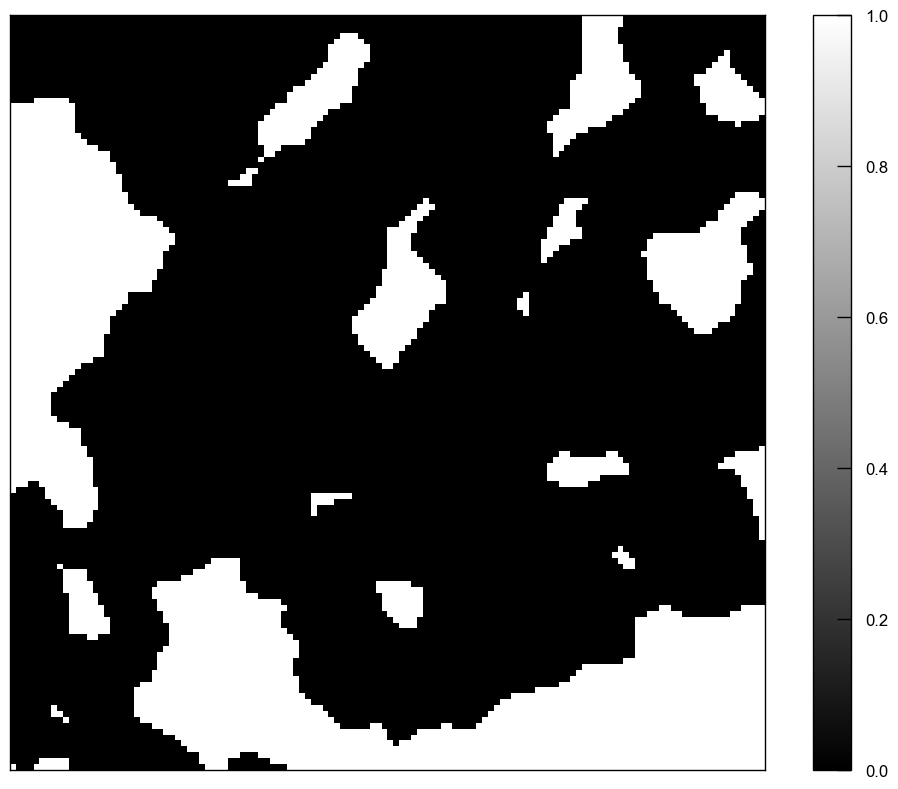

In [19]:
ax1 = plt.figure(figsize = (10,8))


plt.imshow(vacuum_mask, cmap = 'gray')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'vacuum_mask2.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [20]:
data1.data[vacuum_mask] = 0

# EDX Spectra

In [21]:
sum_spectrum = data1.sum()
sum_spectrum.set_signal_type('EDS_TEM')
m = sum_spectrum.create_model()
m.components

   # |      Attribute Name |      Component Name |      Component Type
---- | ------------------- | ------------------- | -------------------
   0 |  background_order_6 |  background_order_6 |          Polynomial
   1 |                C_Ka |                C_Ka |            Gaussian
   2 |               Co_Ka |               Co_Ka |            Gaussian
   3 |               Co_Kb |               Co_Kb |            Gaussian
   4 |               Co_La |               Co_La |            Gaussian
   5 |               Co_Ln |               Co_Ln |            Gaussian
   6 |               Co_Ll |               Co_Ll |            Gaussian
   7 |              Co_Lb3 |              Co_Lb3 |            Gaussian
   8 |               Cu_Ka |               Cu_Ka |            Gaussian
   9 |               Cu_Kb |               Cu_Kb |            Gaussian
  10 |               Cu_La |               Cu_La |            Gaussian
  11 |              Cu_Lb1 |              Cu_Lb1 |            Gaussian
  12 |

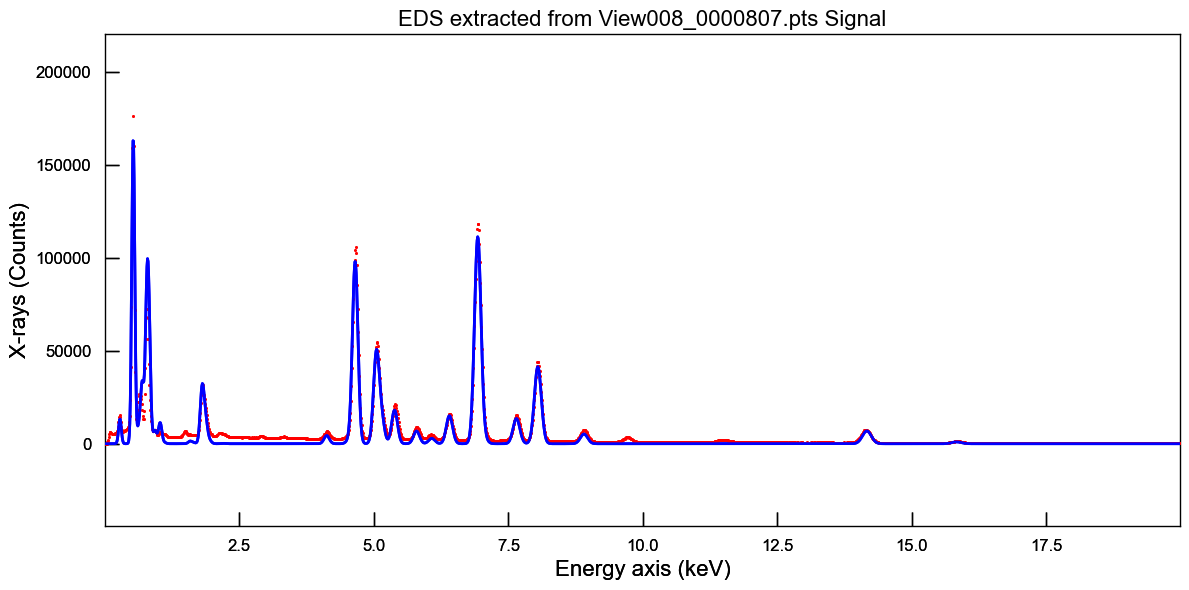

In [22]:
m.plot()

In [23]:
m.fit()

 message: Both actual and predicted relative reductions in the sum of squares
            are at most 0.000000
 success: True
  status: 1
     fun: [ 4.612e+03  4.618e+03 ... -1.855e+02 -2.052e+02]
       x: [ 4.613e+05  5.260e+04 ...  1.463e+05  2.223e+05]
   covar: [[ 3.382e+02 -3.690e+02 ... -2.994e+00  8.152e-01]
           [-3.690e+02  5.582e+02 ...  8.564e+00 -1.143e+01]
           ...
           [-2.994e+00  8.564e+00 ...  3.193e+01 -1.735e-01]
           [ 8.152e-01 -1.143e+01 ... -1.735e-01  9.476e+00]]
    nfev: 61

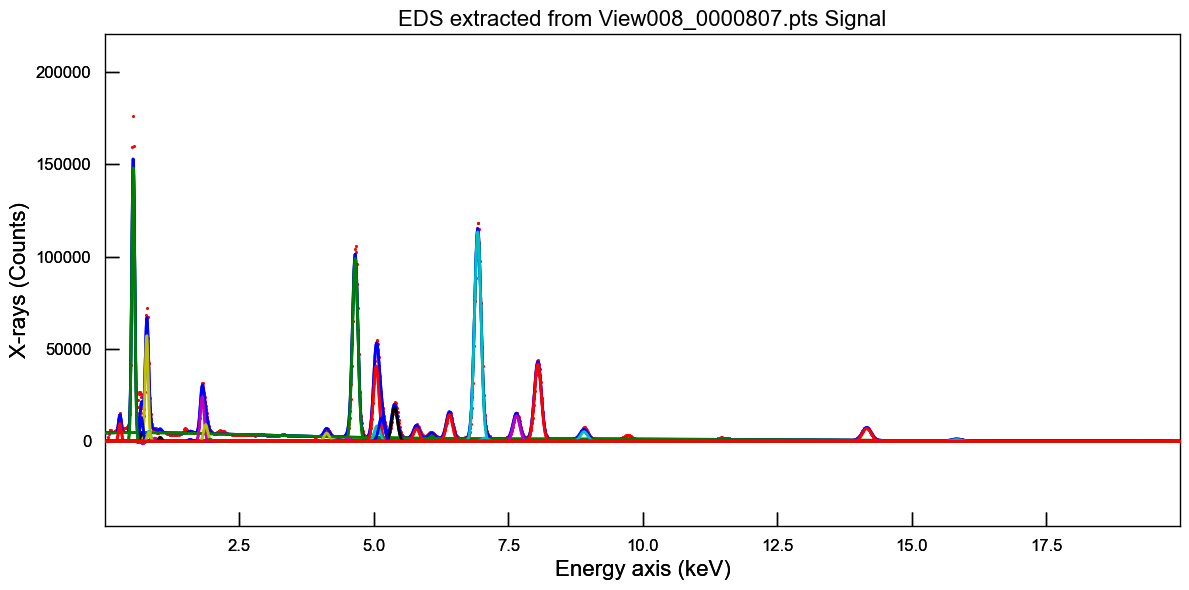

In [24]:
m.plot(plot_components = True)

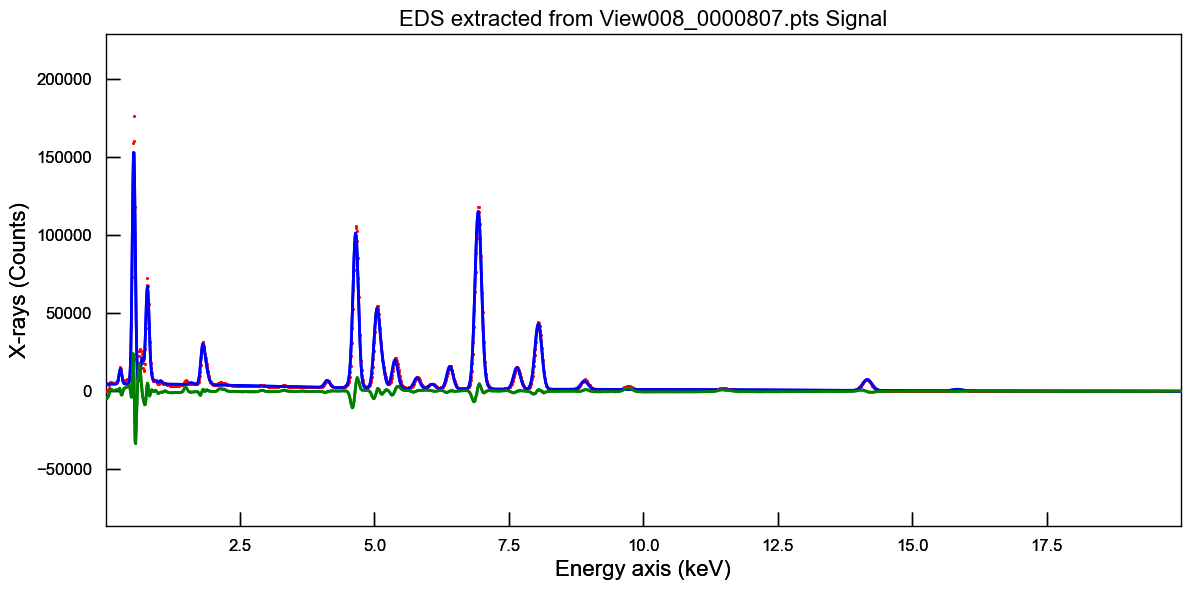

In [25]:
m.plot(plot_residual = True)

In [26]:
lines_intensities = m.get_lines_intensity(xray_lines= ['Co_Ka','La_La','Sr_Ka'])
kfactors = [1.747 ,4.192,5.246]# Co - 1.747 (calc) # 2.114 user #La-La 4.192 #Sr-La 3.869 Ka- 5.246
quant = sum_spectrum.quantification(lines_intensities, 'CL', factors=kfactors, composition_units ='atomic',plot_result =False, take_off_angle= 21.5, max_iterations = 400)
print ('Co (at.%):', quant[0].data)
print ('La (at.%):', quant[1].data)
print ('Sr (at.%):', quant[2].data)

  0%|          | 0/7 [00:00<?, ?it/s]

Co (at.%): [51.94644698]
La (at.%): [39.13175299]
Sr (at.%): [8.92180003]


# EDX Map

# Load data as Lazy signal

In [27]:
# 1. get a lazy view
s_cpu = data1.as_lazy()

# 2. pull the whole signal into RAM (in-place)
s_cpu.compute()  

  0%|          | 0/1 [00:00<?, ?it/s]

In [28]:
m_full = s_cpu.create_model(auto_add_lines= True, auto_background= True)

In [29]:
m_full.components

   # |      Attribute Name |      Component Name |      Component Type
---- | ------------------- | ------------------- | -------------------
   0 |  background_order_6 |  background_order_6 |          Polynomial
   1 |                C_Ka |                C_Ka |            Gaussian
   2 |               Co_Ka |               Co_Ka |            Gaussian
   3 |               Co_Kb |               Co_Kb |            Gaussian
   4 |               Co_La |               Co_La |            Gaussian
   5 |               Co_Ln |               Co_Ln |            Gaussian
   6 |               Co_Ll |               Co_Ll |            Gaussian
   7 |              Co_Lb3 |              Co_Lb3 |            Gaussian
   8 |               Cu_Ka |               Cu_Ka |            Gaussian
   9 |               Cu_Kb |               Cu_Kb |            Gaussian
  10 |               Cu_La |               Cu_La |            Gaussian
  11 |              Cu_Lb1 |              Cu_Lb1 |            Gaussian
  12 |

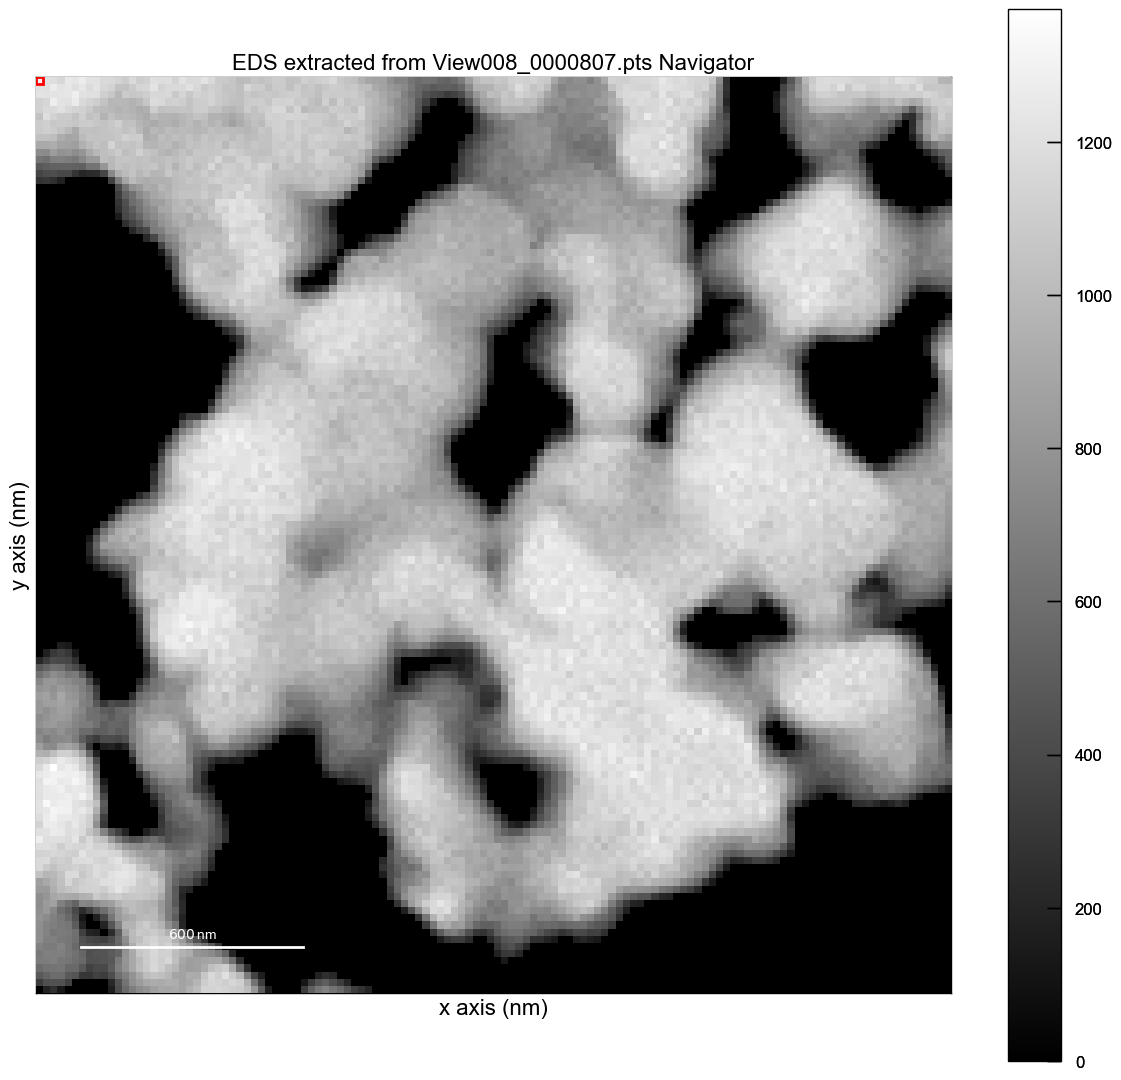

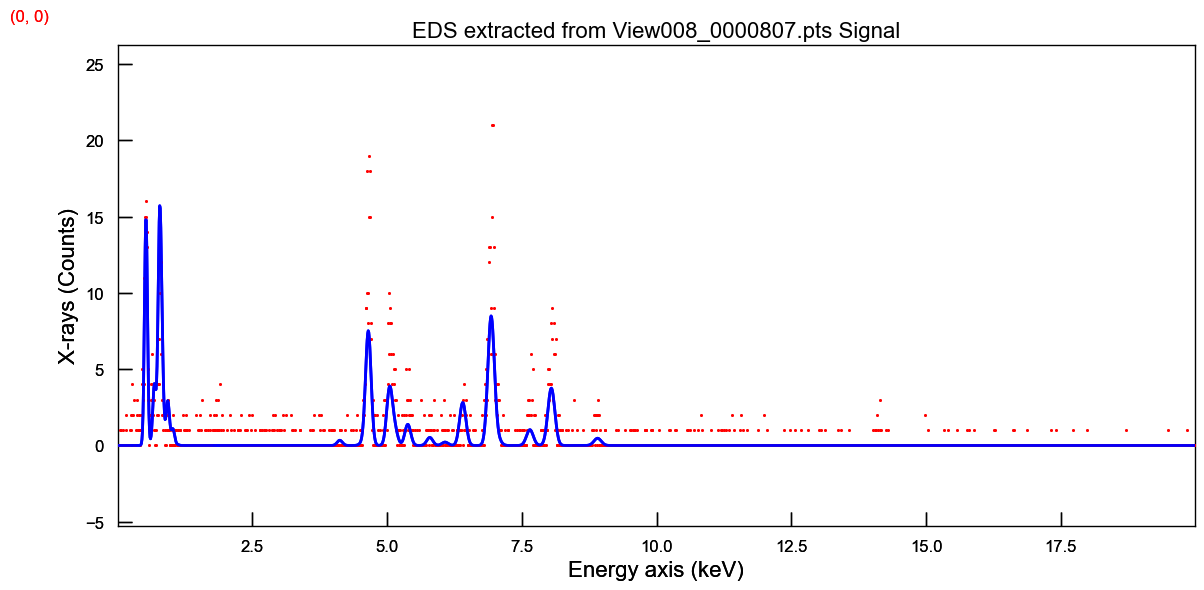

In [30]:
m_full.plot(plot_components=False)

In [31]:
m_full.multifit(optimizer="lstsq", loss_function = 'ls',mask = vacuum_mask)   
# CPU solve (~1 min on 8 cores)##mask values are true and will be skipped

In [32]:
intensities = m_full.get_lines_intensity(xray_lines= ['Co_Ka','La_La','Sr_Ka'])

In [33]:
#fitting residue

In [34]:
m_full.components

   # |      Attribute Name |      Component Name |      Component Type
---- | ------------------- | ------------------- | -------------------
   0 |  background_order_6 |  background_order_6 |          Polynomial
   1 |                C_Ka |                C_Ka |            Gaussian
   2 |               Co_Ka |               Co_Ka |            Gaussian
   3 |               Co_Kb |               Co_Kb |            Gaussian
   4 |               Co_La |               Co_La |            Gaussian
   5 |               Co_Ln |               Co_Ln |            Gaussian
   6 |               Co_Ll |               Co_Ll |            Gaussian
   7 |              Co_Lb3 |              Co_Lb3 |            Gaussian
   8 |               Cu_Ka |               Cu_Ka |            Gaussian
   9 |               Cu_Kb |               Cu_Kb |            Gaussian
  10 |               Cu_La |               Cu_La |            Gaussian
  11 |              Cu_Lb1 |              Cu_Lb1 |            Gaussian
  12 |

In [35]:
#model_data = m_full.as_signal(component_list= [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19])####no plotting window must be open 
model_data = m_full.as_signal(component_list= [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
                                              ,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
                                              ,37,38,39,40,41,42,43])
model_data.axes_manager = data1.axes_manager

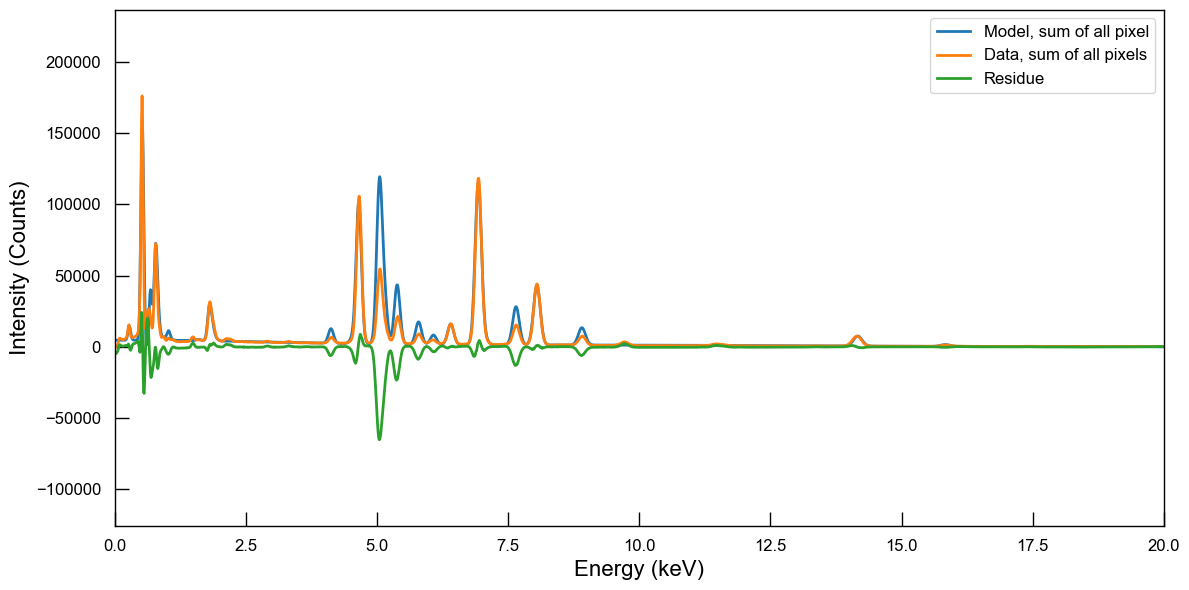

In [36]:
##quick way to estimate global or average fitting
plt.figure()

plt.plot(data1.axes_manager[-1].axis,model_data.sum(),label = "Model, sum of all pixel")
plt.plot(data1.axes_manager[-1].axis,data1.sum(),label = "Data, sum of all pixels")
plt.plot(data1.axes_manager[-1].axis,data1.sum()-model_data.sum(),label = "Residue")
plt.xlabel('Energy (keV)')
plt.ylabel('Intensity (Counts)')
plt.legend()
plt.xlim(0,20)
plt.legend()
plt.tight_layout()



In [ ]:
plt.savefig(r'Sum-spectrum_fit2.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
plt.savefig(r'Sum-spectrum_fit2.svg', dpi=600, format='svg', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [37]:
residue = (data1 - model_data).data
rel_err = np.sqrt(np.sum(residue**2, axis =2)/(np.sum(data1.data**2,axis =2)))

rel_err[np.isnan(rel_err)] =0
rel_err[np.isinf(rel_err)] =0

C:\Users\nagaa\AppData\Local\Temp\ipykernel_44328\47230293.py:2: RuntimeWarning: divide by zero encountered in divide
  rel_err = np.sqrt(np.sum(residue**2, axis =2)/(np.sum(data1.data**2,axis =2)))


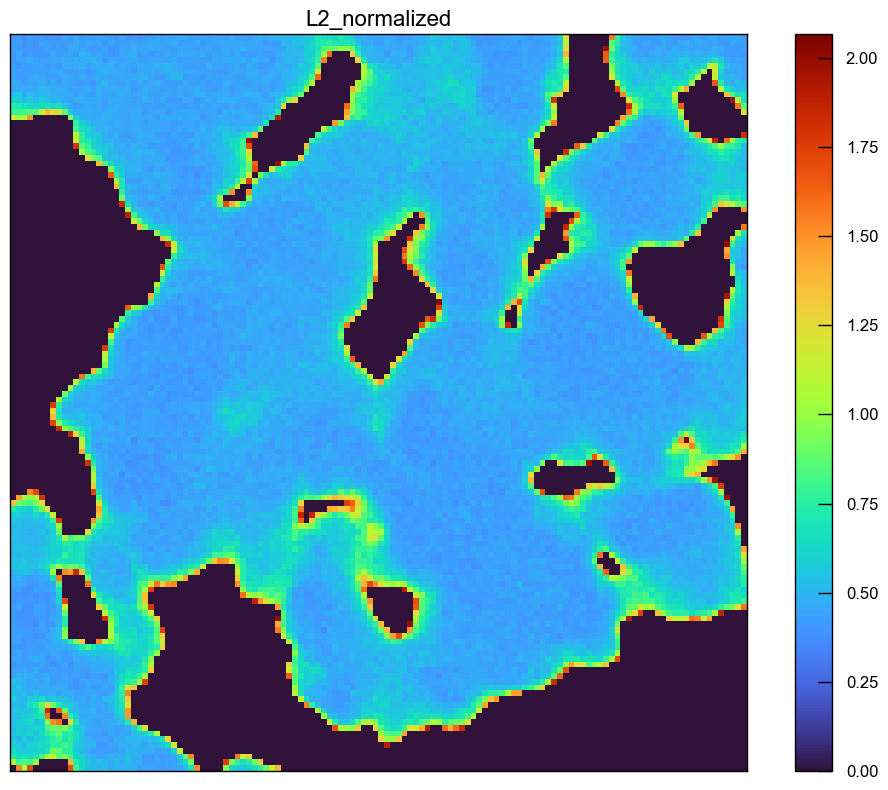

In [38]:
ax1 = plt.figure(figsize = (10,8))

plt.imshow(rel_err, cmap = 'turbo', interpolation = 'none')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.title('L2_normalized')
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'L2_normalized.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

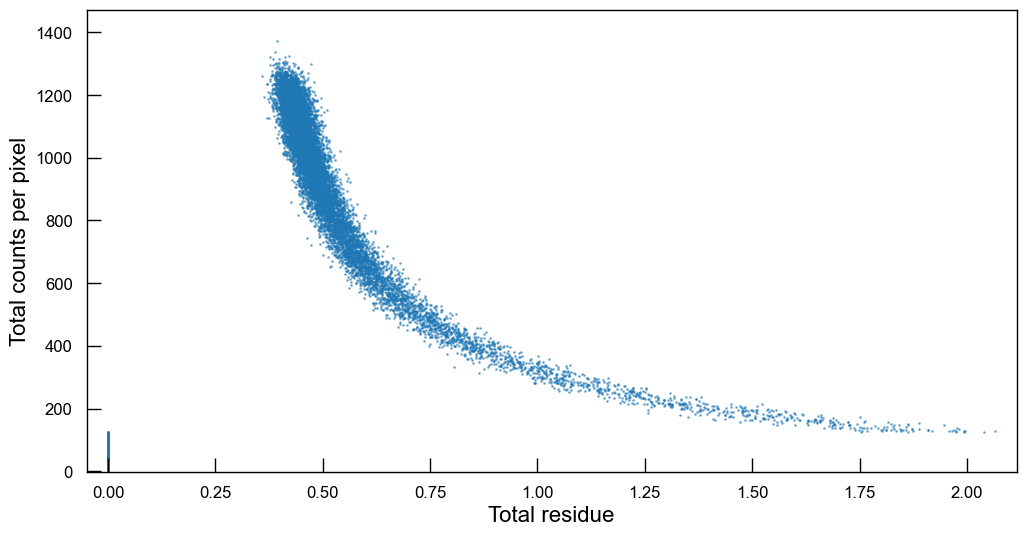

In [39]:
plt.figure ()
x = rel_err.ravel()
y = total_counts.ravel()

plt.scatter(x, y, s=1, alpha = 0.5,)
plt.ylim(-1, total_counts.max()+100)
plt.xlim(rel_err.min()-0.05, rel_err.max()+0.05)
plt.xlabel("Total residue")
plt.ylabel("Total counts per pixel")
plt.show()


In [ ]:
plt.savefig(r'L2_total_counts.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
plt.savefig(r'L2_total_counts.svg', dpi=600, format='svg', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [40]:
La_raw = data1.isig[4.4:4.85]
La_model  = model_data.isig[4.4:4.85]

Co_raw = data1.isig[6.65:7.27]
Co_model = model_data.isig[6.65:7.27]

Sr_raw = data1.isig[13.9: 14.4]
Sr_model = model_data.isig[13.9: 14.4]
#Sr_model = model_data.isig[1.67: 2.0]

In [41]:
La_residue = (La_raw - La_model).data
La_rel_err = np.sqrt(np.sum(La_residue**2, axis =2)/(np.sum(La_raw.data**2,axis =2)))
La_rel_err[np.isnan(La_rel_err)] =0
La_rel_err[np.isinf(La_rel_err)] =0

C:\Users\nagaa\AppData\Local\Temp\ipykernel_44328\75142206.py:2: RuntimeWarning: divide by zero encountered in divide
  La_rel_err = np.sqrt(np.sum(La_residue**2, axis =2)/(np.sum(La_raw.data**2,axis =2)))


In [42]:
Co_residue = (Co_raw - Co_model).data
Co_rel_err = np.sqrt(np.sum(Co_residue**2, axis =2)/(np.sum(Co_raw.data**2,axis =2)))
Co_rel_err[np.isnan(Co_rel_err)] =0
Co_rel_err[np.isinf(Co_rel_err)] =0

C:\Users\nagaa\AppData\Local\Temp\ipykernel_44328\534454997.py:2: RuntimeWarning: divide by zero encountered in divide
  Co_rel_err = np.sqrt(np.sum(Co_residue**2, axis =2)/(np.sum(Co_raw.data**2,axis =2)))


In [43]:
Sr_residue = (Sr_raw - Sr_model).data
Sr_rel_err = np.sqrt(np.sum(Sr_residue**2, axis =2)/(np.sum(Sr_raw.data**2,axis =2)))
Sr_rel_err[np.isnan(Sr_rel_err)] =0
Sr_rel_err[np.isinf(Sr_rel_err)] =0

C:\Users\nagaa\AppData\Local\Temp\ipykernel_44328\2868809376.py:2: RuntimeWarning: divide by zero encountered in divide
  Sr_rel_err = np.sqrt(np.sum(Sr_residue**2, axis =2)/(np.sum(Sr_raw.data**2,axis =2)))


In [44]:
max_value  = max(La_rel_err.max(), Sr_rel_err.max(), Co_rel_err.max())

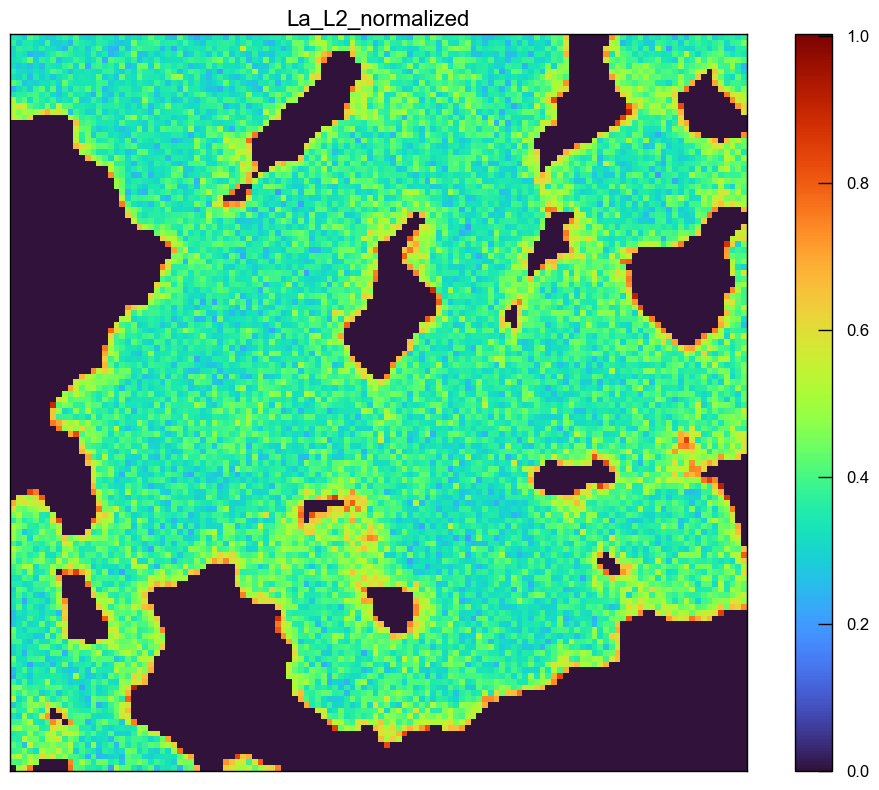

In [45]:
ax1 = plt.figure(figsize = (10,8))

plt.imshow(La_rel_err, cmap = 'turbo', vmax = max_value)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.title('La_L2_normalized')
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'La_L2_normalized.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
ax1 = plt.figure(figsize = (10,8))

plt.imshow(Co_rel_err, cmap = 'turbo', vmax = max_value, interpolation = 'none')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.title('Co_L2_normalized')
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'Co_L2_normalized.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
ax1 = plt.figure(figsize = (10,8))

plt.imshow(Sr_rel_err, cmap = 'turbo', vmax = max_value, interpolation = 'none')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.title('Sr_L2_normalized')
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'Sr_L2_normalized.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [46]:
kfactors = [1.747 ,4.192,5.246]# Co - 1.747 (calc) # 2.114 user #La-La 4.192 #Sr-La 3.869 Ka- 5.246

In [47]:
quant = data1.quantification(intensities, 'CL', factors=kfactors, composition_units ='atomic', navigation_mask = vacuum_mask,plot_result =False, take_off_angle= 21.5, max_iterations = 400)

  0%|          | 0/7 [00:00<?, ?it/s]

C:\Users\nagaa\HyperSpy-bundle\Lib\site-packages\exspy\_misc\material.py:67: RuntimeWarning: invalid value encountered in divide
  atomic_percent[i] /= sum_weight


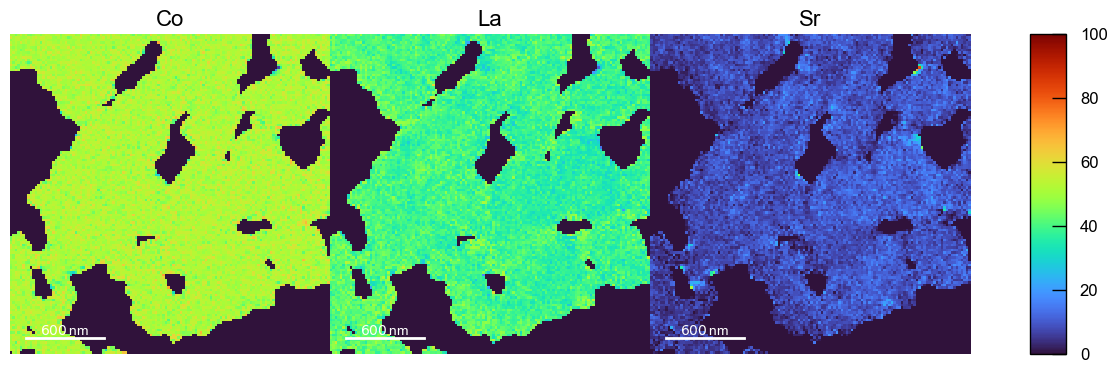

In [48]:
map_plot = hs.plot.plot_images(quant,
        tight_layout=False,cmap= 'turbo', axes_decor='off', vmin = 0, vmax =100,
        colorbar='single', label = ['Co','La','Sr'], scalebar = 'all', interpolation = 'none',
                               scalebar_color='white', padding={'top':0.9, 'bottom':0.10, 'left':0.05,
                                         'right':0.85, 'wspace':0.0, 'hspace':0.05})

In [ ]:

plt.savefig(r'Quant_map.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:

plt.savefig(r'Quant_map_La.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:

plt.savefig(r'Quant_map_Co.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
quant

# Ternary plot

In [49]:
Co_map = quant[0].data
La_map = quant[1].data
Sr_map = quant[2].data

In [50]:
La_map[np.isnan(La_map)] = 0
Co_map[np.isnan(Co_map)] = 0
Sr_map[np.isnan(Sr_map)] = 0

C:\Users\nagaa\HyperSpy-bundle\Lib\site-packages\mpltern\ternary\transforms.py:290: RuntimeWarning: invalid value encountered in divide
  return (values / np.sum(values, axis=1)[:, None]) @ self.corners


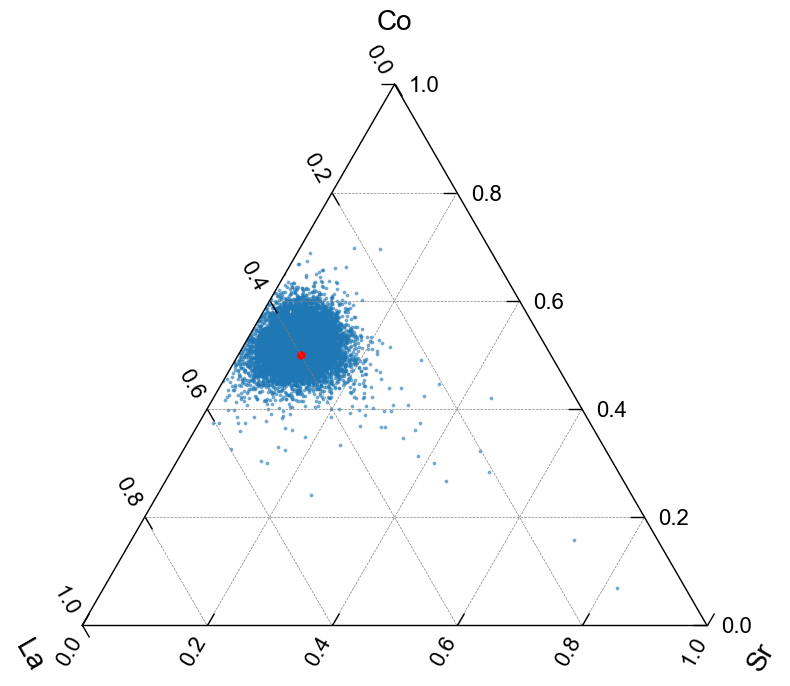

In [51]:
#Ternary plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpltern

# --- Flatten raw maps into 1D arrays ---
sr_vals = Sr_map.flatten()
la_vals = La_map.flatten()
co_vals = Co_map.flatten()

# --- Compute total composition per pixel ---
total = sr_vals + la_vals + co_vals

# --- Filtering conditions ---
valid_pixels = (total == 100)

# --- Apply mask to get valid data points ---
sr_valid = sr_vals
la_valid = la_vals
co_valid = co_vals



# --- Plot using mpltern ---
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection='ternary')

# Scatter plot with Sr color mapping (absolute raw Sr values)
sc = ax.scatter(co_valid, la_valid, sr_valid,
                 s=3, alpha=0.5)#c=sr_valid, cmap='turbo',
target = ax.scatter(50, 40, 10, c = 'red', s = 25, alpha = 1.0)

# Axis labels (keeping the same convention as Plotly a=Co, b=La, c=Sr)
ax.set_rlabel("Sr", fontsize = 20)
ax.set_llabel("La", fontsize = 20)
ax.set_tlabel("Co", fontsize = 20)

# Grid lines and ticks styling
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()

plt.show()


In [ ]:
plt.savefig(r'ternary.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

Mean: 8.82, Std: 3.85, Skewness: 1.90
Mean: 39.36, Std: 4.09, Skewness: 0.22
Mean: 51.91, Std: 3.72, Skewness: -0.43


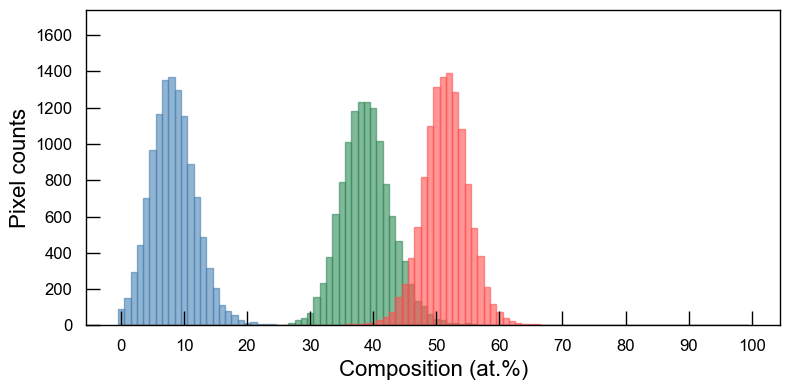

In [52]:
from scipy.stats import norm, skew
# Example data: 1024x1024 array with values between 0 and 100
array_Sr = Sr_map
array_La = La_map
array_Co = Co_map

non_zero_values_Sr = array_Sr[array_Sr > 0]
non_zero_values_La = array_La[array_La > 0]
non_zero_values_Co = array_Co[array_Co > 0]

# Compute histogram
counts_Sr, bin_edges_Sr = np.histogram(non_zero_values_Sr, bins=100, range=(0, 100),)
counts_La, bin_edges_La = np.histogram(non_zero_values_La, bins=100, range=(0, 100),)
counts_Co, bin_edges_Co = np.histogram(non_zero_values_Co, bins=100, range=(0, 100),)

# Compute statistical parameters
mean_Sr = np.mean(non_zero_values_Sr)
std_Sr = np.std(non_zero_values_Sr)
skewness_Sr = skew(non_zero_values_Sr)

mean_La = np.mean(non_zero_values_La)
std_La = np.std(non_zero_values_La)
skewness_La = skew(non_zero_values_La)

mean_Co = np.mean(non_zero_values_Co)
std_Co = np.std(non_zero_values_Co)
skewness_Co = skew(non_zero_values_Co)

print(f"Mean: {mean_Sr:.2f}, Std: {std_Sr:.2f}, Skewness: {skewness_Sr:.2f}")
print(f"Mean: {mean_La:.2f}, Std: {std_La:.2f}, Skewness: {skewness_La:.2f}")
print(f"Mean: {mean_Co:.2f}, Std: {std_Co:.2f}, Skewness: {skewness_Co:.2f}")

# Plot histogram and Gaussian curve
plt.figure(figsize=(8, 4))
plt.bar(bin_edges_Sr[:-1], counts_Sr, width=bin_edges_Sr[1] - bin_edges_Sr[0],
        color='steelblue', edgecolor='steelblue', alpha=0.6, label='Histogram (data)')

plt.bar(bin_edges_La[:-1], counts_La, width=bin_edges_La[1] - bin_edges_La[0],
        color ='seagreen' ,edgecolor='seagreen', alpha=0.6, label='Histogram (data)')

plt.bar(bin_edges_Co[:-1], counts_Co, width=bin_edges_Co[1] - bin_edges_Co[0],
        color='#ff5050', edgecolor='#ff5050', alpha=0.6, label='Histogram (data)')

plt.xlabel("Composition (at.%)")
plt.ylabel("Pixel counts")
#plt.legend()
plt.xticks([0,10,20,30,40,50,60,70,80,90,100])
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(r'Quant_map_histogram.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)


Cluster Summary (Ordered by Sr):
   Cluster  Fraction    Mean_Co    Mean_La    Mean_Sr  New_Cluster
0        0  0.262268   0.000000   0.000000   0.000000            0
1        4  0.142700  53.280572  43.042747   3.676682            1
2        1  0.294617  52.496969  39.932660   7.570370            2
3        2  0.246155  51.203325  37.530040  11.266635            3
4        3  0.054260  48.280650  34.927003  16.792347            4


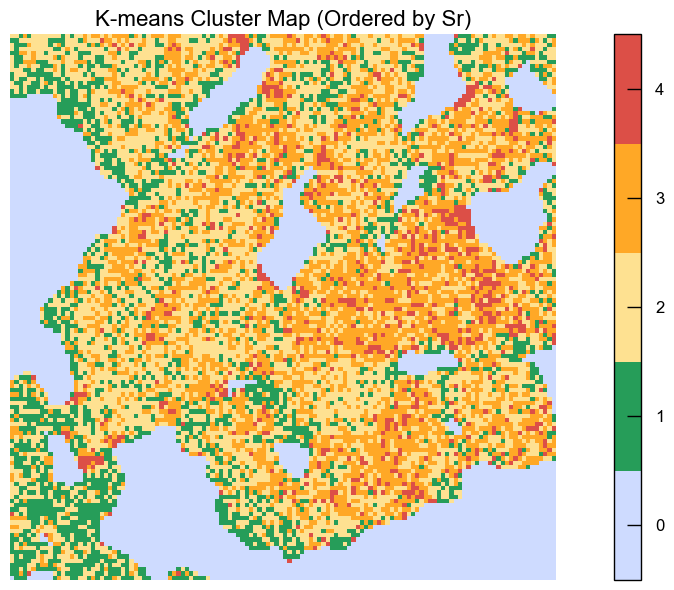

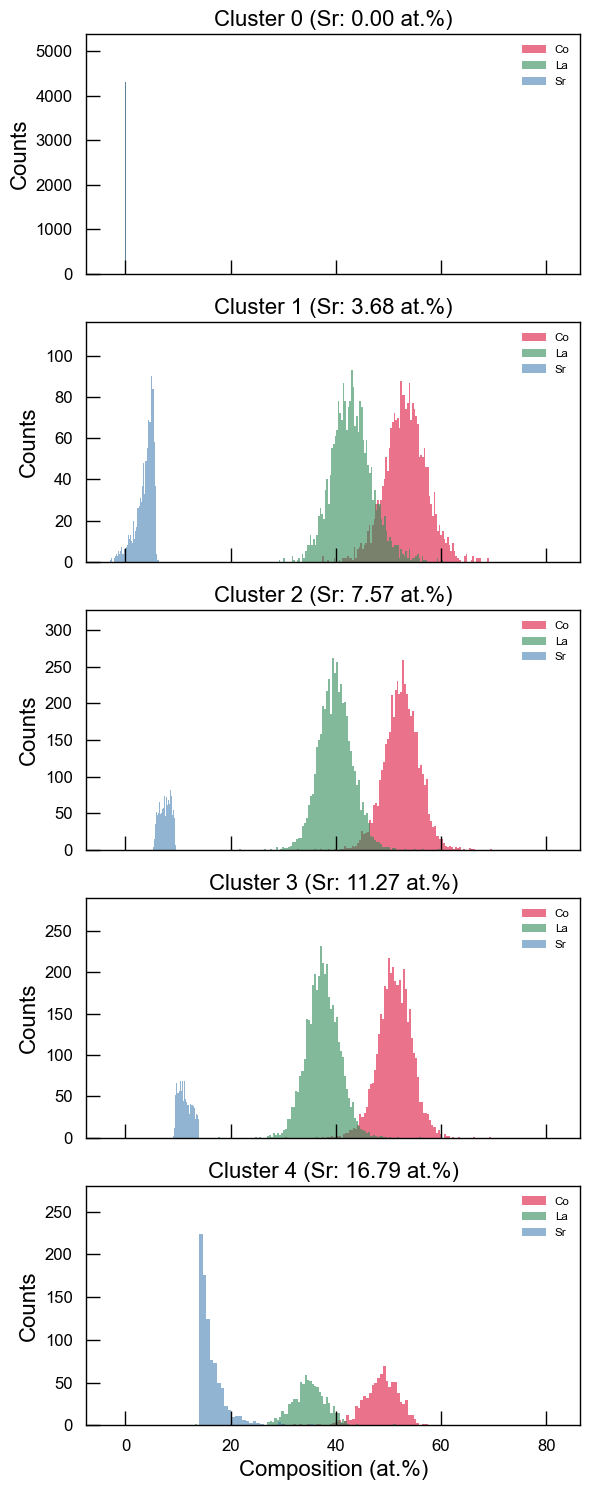

In [54]:
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ----------------------------
# Rebin function
def rebin(arr, new_shape):
    """Rebin 2D array to smaller shape by averaging."""
    shape = (new_shape[0], arr.shape[0] // new_shape[0],
             new_shape[1], arr.shape[1] // new_shape[1])
    return arr.reshape(shape).mean(-1).mean(1)

# ----------------------------
# Rebin element maps
target_shape = (128, 128)
co_map = rebin(Co_map, target_shape)
la_map = rebin(La_map, target_shape)
sr_map = rebin(Sr_map, target_shape)

# ----------------------------
# Prepare data for clustering
X = np.stack([co_map.ravel(), la_map.ravel(), sr_map.ravel()], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# Run KMeans clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)
labels_image = labels.reshape(target_shape)

# ----------------------------
# Compute cluster statistics
cluster_stats = []
for i in range(n_clusters):
    mask = labels == i
    cluster_stats.append({
        'Cluster': i,
        'Fraction': np.sum(mask) / len(labels),
        'Mean_Co': co_map.ravel()[mask].mean(),
        'Mean_La': la_map.ravel()[mask].mean(),
        'Mean_Sr': sr_map.ravel()[mask].mean()
    })

df_clusters = pd.DataFrame(cluster_stats)

# ----------------------------
# Reorder clusters based on ascending Sr
sorted_clusters = df_clusters.sort_values('Mean_Sr')['Cluster'].tolist()
cluster_remap = {old: new for new, old in enumerate(sorted_clusters)}

# Apply relabeling
labels_remapped = np.vectorize(cluster_remap.get)(labels)
labels_image_remapped = labels_remapped.reshape(target_shape)

# Remap and sort stats for reporting and histogram plotting
df_clusters['New_Cluster'] = df_clusters['Cluster'].map(cluster_remap)
df_clusters = df_clusters.sort_values('New_Cluster').reset_index(drop=True)

print("\nCluster Summary (Ordered by Sr):")
print(df_clusters)

# ----------------------------
# Plot cluster map
cluster_colors = ['#ccd9ff',  # blue
                  '#1a9850',  # green
                  '#fee08b',  # yellow-orange
                  '#ffa31a',  # yellow                
                  '#db453d']  # red
custom_cmap = ListedColormap(cluster_colors[:n_clusters])

plt.figure()
plt.imshow(labels_image_remapped, cmap=custom_cmap, alpha=0.95)
plt.title('K-means Cluster Map (Ordered by Sr)')
plt.axis('off')

# Colorbar
cbar = plt.colorbar(ticks=np.arange(n_clusters))
cbar.ax.set_yticklabels([f'Cluster {i}' for i in range(n_clusters)])
plt.clim(-0.5, n_clusters - 0.5)
plt.tight_layout()
plt.show()

# ----------------------------
# Histograms by reordered clusters
bins = 100
fig, axes = plt.subplots(n_clusters, 1,
                         figsize=(6, 3 * n_clusters),
                         sharex=True)

for i, ax in enumerate(axes):
    mask = labels_remapped == i  # <== use remapped labels here
    ax.hist(co_map.ravel()[mask], bins=bins, density=False,
            alpha=0.6, label='Co', color='crimson')
    ax.hist(la_map.ravel()[mask], bins=bins, density=False,
            alpha=0.6, label='La', color='seagreen')
    ax.hist(sr_map.ravel()[mask], bins=bins, density=False,
            alpha=0.6, label='Sr', color='steelblue')
    
    ax.set_title(f'Cluster {i} (Sr: {df_clusters.loc[i, "Mean_Sr"]:.2f} at.%)')
    ax.set_ylabel('Counts')
    ax.legend(frameon=False, fontsize='small')

axes[-1].set_xlabel('Composition (at.%)')
fig.tight_layout()
plt.show()


In [ ]:
df_clusters.to_excel("df_clusters_128x128.xlsx")

In [ ]:
plt.savefig(r'Cluster_map_histogram.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

In [ ]:
plt.savefig(r'Cluster_map.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)

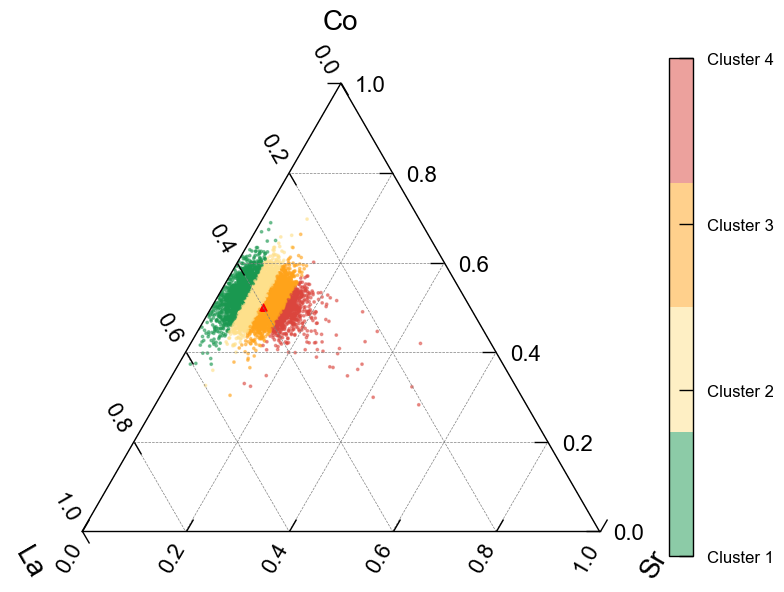

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpltern
from matplotlib.colors import ListedColormap

# Assume cluster 0 (vacuum) has already been removed from labels_image_remapped
# and that you have exactly 4 remaining clusters: 0, 1, 2, 3 (Sr-sorted)

n_clusters = 4
cluster_colors = [
    '#1a9850',  # Cluster 0 (green)
    '#fee08b',  # Cluster 1 (yellow-orange)
    '#ffa31a',  # Cluster 2 (yellow)
    '#db453d'   # Cluster 3 (red)
]
custom_cmap = ListedColormap(cluster_colors)

# --- Flatten rebinned maps and labels ---
sr_vals = Sr_map.flatten()
la_vals = La_map.flatten()
co_vals = Co_map.flatten()
label_vals = labels_image_remapped.flatten()  # ✅ Use remapped labels!

# --- Total composition per pixel ---
total = sr_vals + la_vals + co_vals
valid_mask = (total == 100) & (label_vals >= 0)  # ✅ Mask out vacuum (-1)

# --- Apply mask ---
sr_valid = sr_vals[valid_mask]
la_valid = la_vals[valid_mask]
co_valid = co_vals[valid_mask]
cluster_valid = label_vals[valid_mask]

# --- Ternary plot ---
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection='ternary')

sc = ax.scatter(co_valid, la_valid, sr_valid,
                c=cluster_valid, cmap=custom_cmap,
                s=3, alpha=0.5)

# Optional target
ax.scatter(50, 40, 10, c='red', s=25, alpha=1.0, marker='^')

# Labels
ax.set_rlabel("Sr", fontsize=20)
ax.set_llabel("La", fontsize=20)
ax.set_tlabel("Co", fontsize=20)
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.tick_params(axis='both', labelsize=16)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, ticks=np.arange(n_clusters+1), shrink=0.75, pad=0.1)
cbar.ax.set_yticklabels([f'Cluster {i}' for i in range(0,5,1)])

plt.tight_layout()
plt.show()


In [ ]:
plt.savefig(r'Cluster_map_ternary.png', dpi=600, format='png', metadata=None, bbox_inches=None, pad_inches=0.0,
          facecolor='auto', edgecolor='auto', backend=None)